In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.style.use('ggplot')

In [3]:
data = pd.read_csv('train.csv')
data.head()

,Unnamed: 0,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,68,859471,B,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,...,10.31,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
1,181,873593,M,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,...,26.68,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
2,63,859196,B,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,...,10.01,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
3,248,88466802,B,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,...,12.25,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
4,60,858970,B,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,...,11.02,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020


In [4]:
data.drop(columns=['Unnamed: 0', 'id'], inplace=True)

In [5]:
data.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

In [6]:
data.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

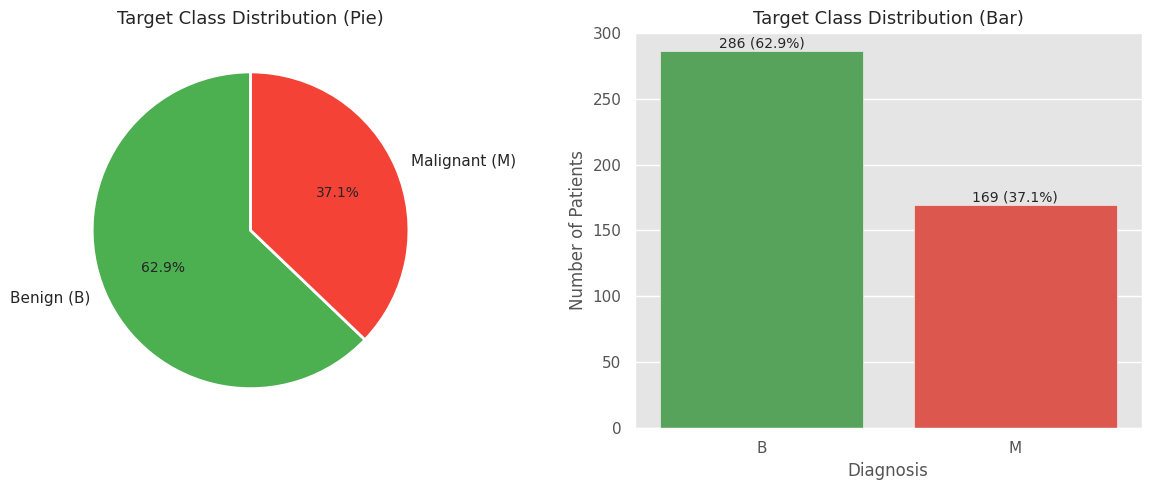

diagnosis
B    62.857143
M    37.142857


In [7]:
counts = data['diagnosis'].value_counts()
pcts   = counts / len(data) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(counts, labels=['Benign (B)', 'Malignant (M)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Target Class Distribution (Pie)', fontsize=13)

sns.countplot(x='diagnosis', data=data, palette={'B': '#4CAF50', 'M': '#F44336'}, ax=axes[1])
axes[1].set_title('Target Class Distribution (Bar)', fontsize=13)
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Number of Patients')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())} ({p.get_height()/len(data)*100:.1f}%)',
                     (p.get_x()+p.get_width()/2, p.get_height()+3), ha='center')

plt.tight_layout()
plt.show()
print(pcts.to_string())

In [8]:
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})
print("Encoding completed → M=1, B=0")
data.head()

Encoding completed → M=1, B=0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,0,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,...,10.31,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
1,1,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,...,26.68,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
2,0,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,...,10.01,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
3,0,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,...,12.25,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
4,0,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,...,11.02,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020


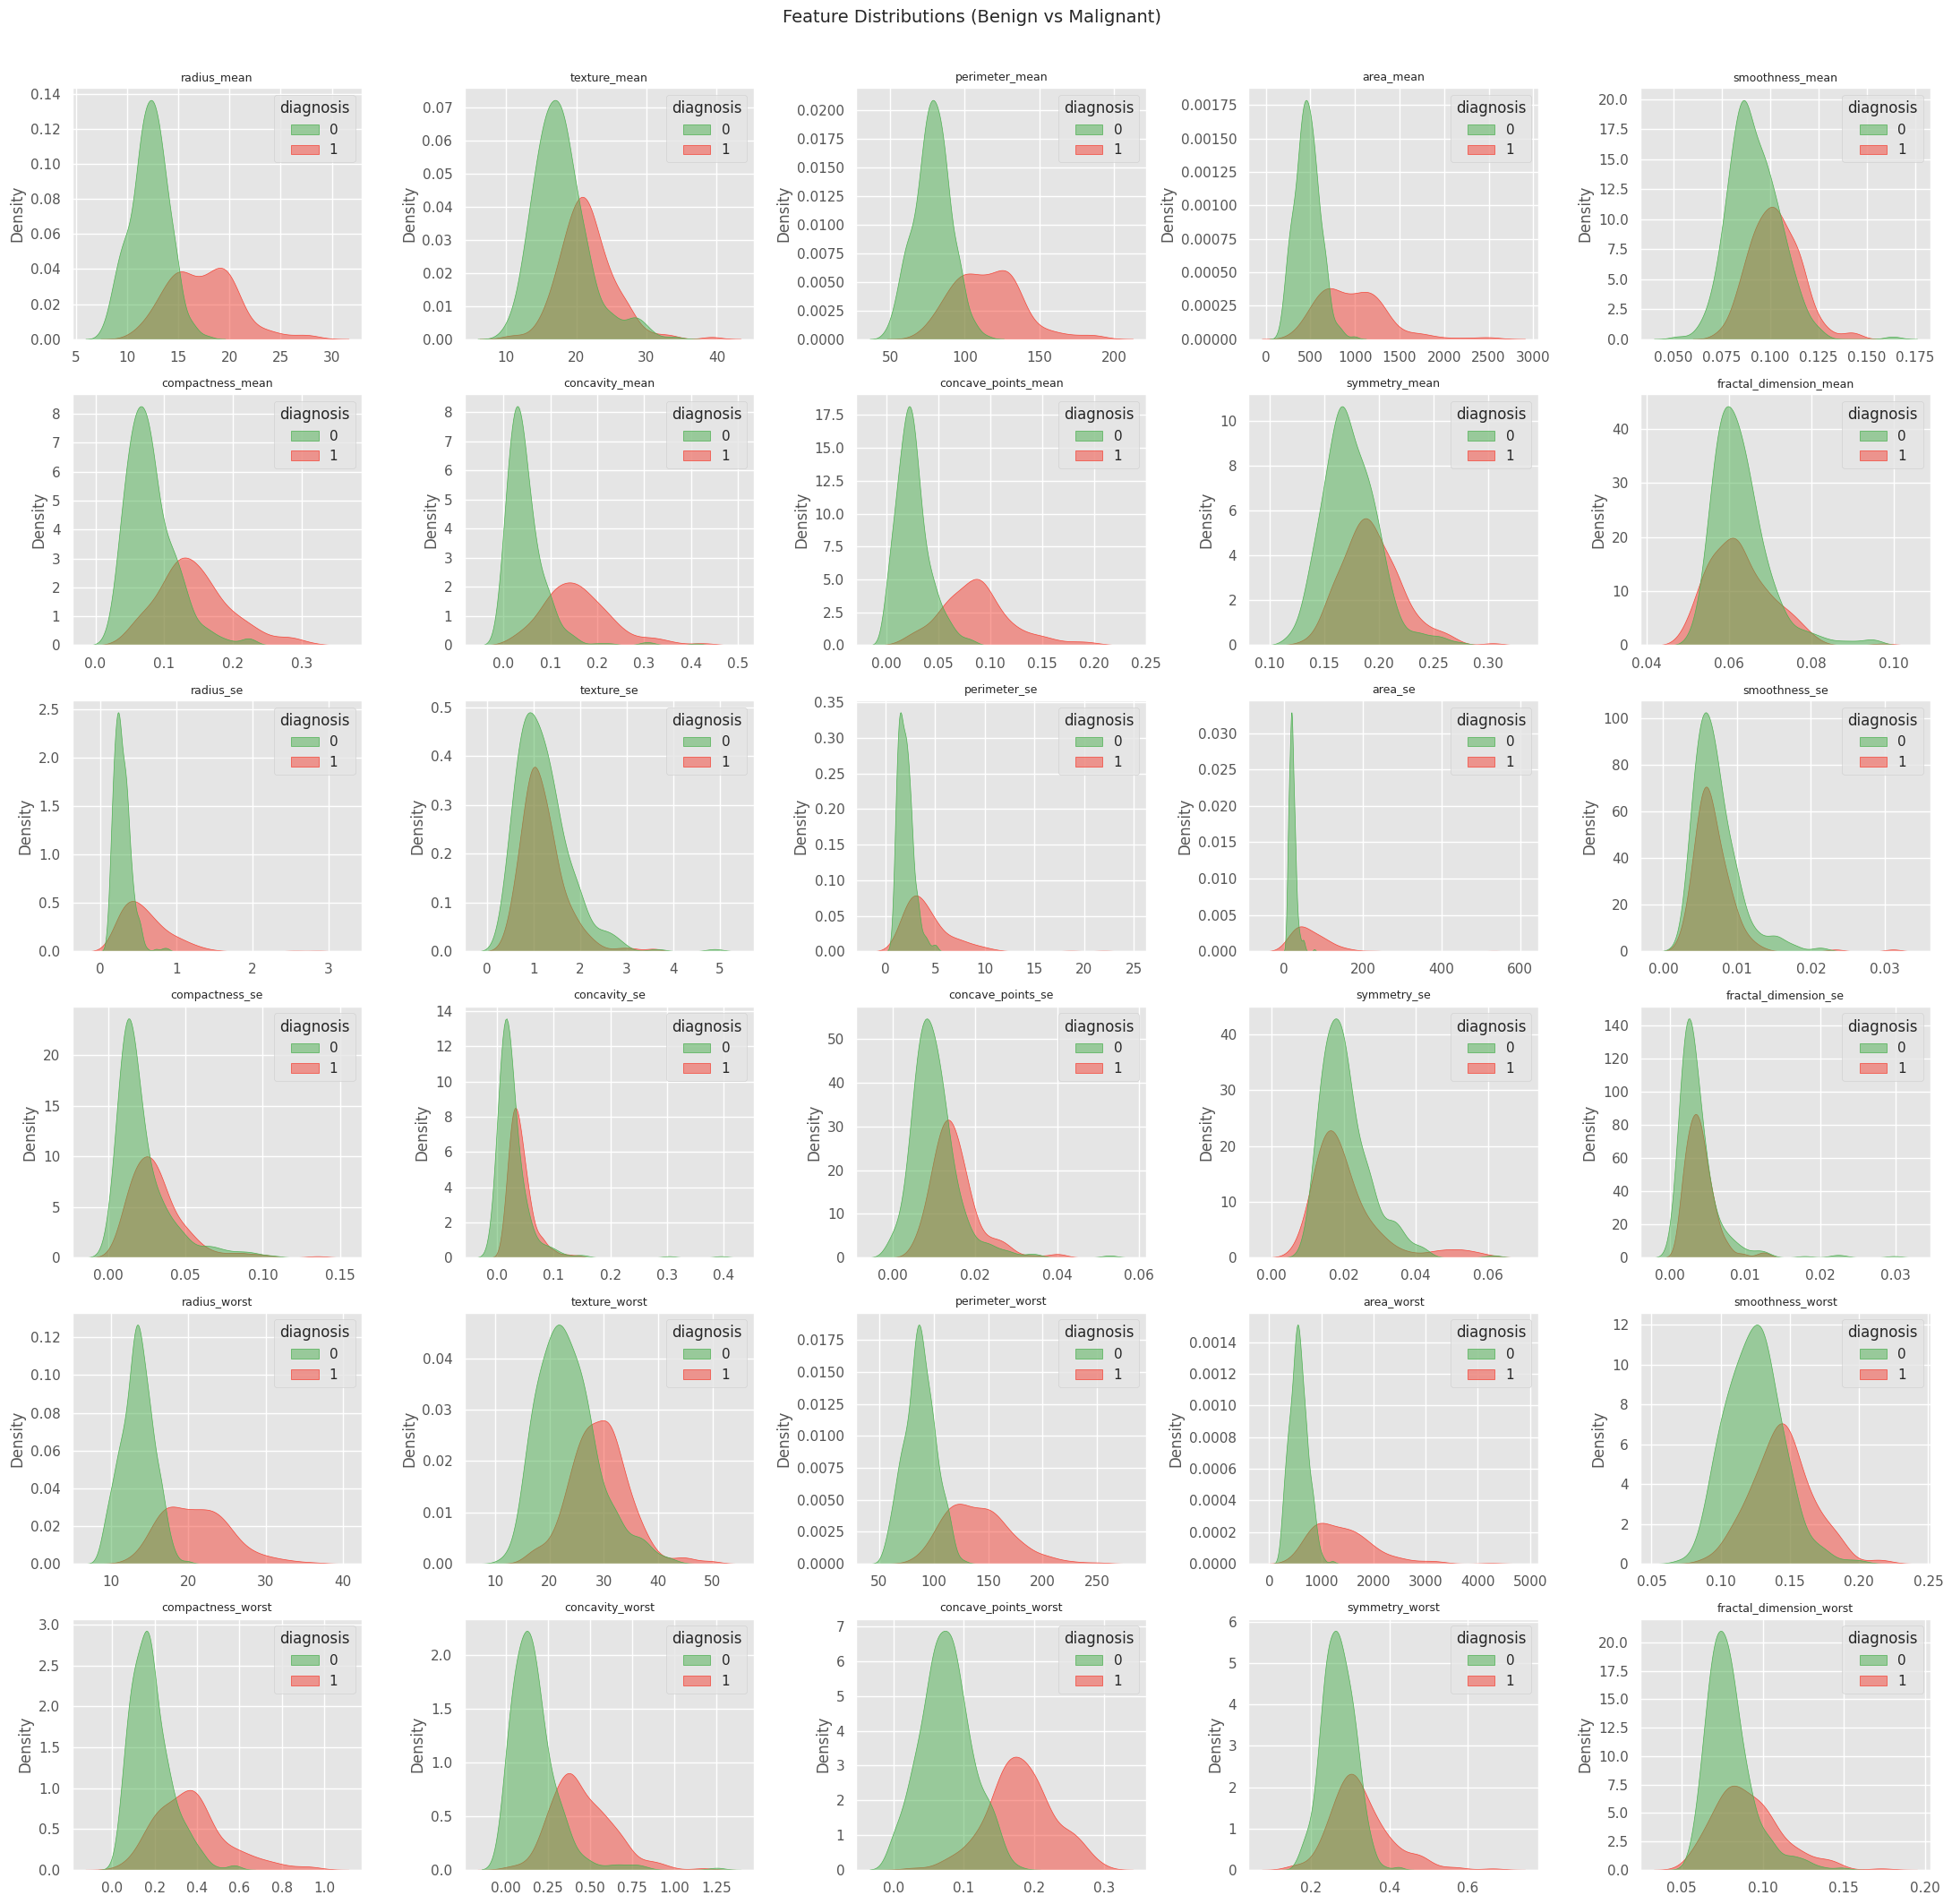

In [10]:
feature_cols = [c for c in data.columns if c not in ['diagnosis']]
n = len(feature_cols)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.kdeplot(data=data, x=col, hue='diagnosis', fill=True,
                palette={0: '#4CAF50', 1: '#F44336'}, alpha=0.5, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions (Benign vs Malignant)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

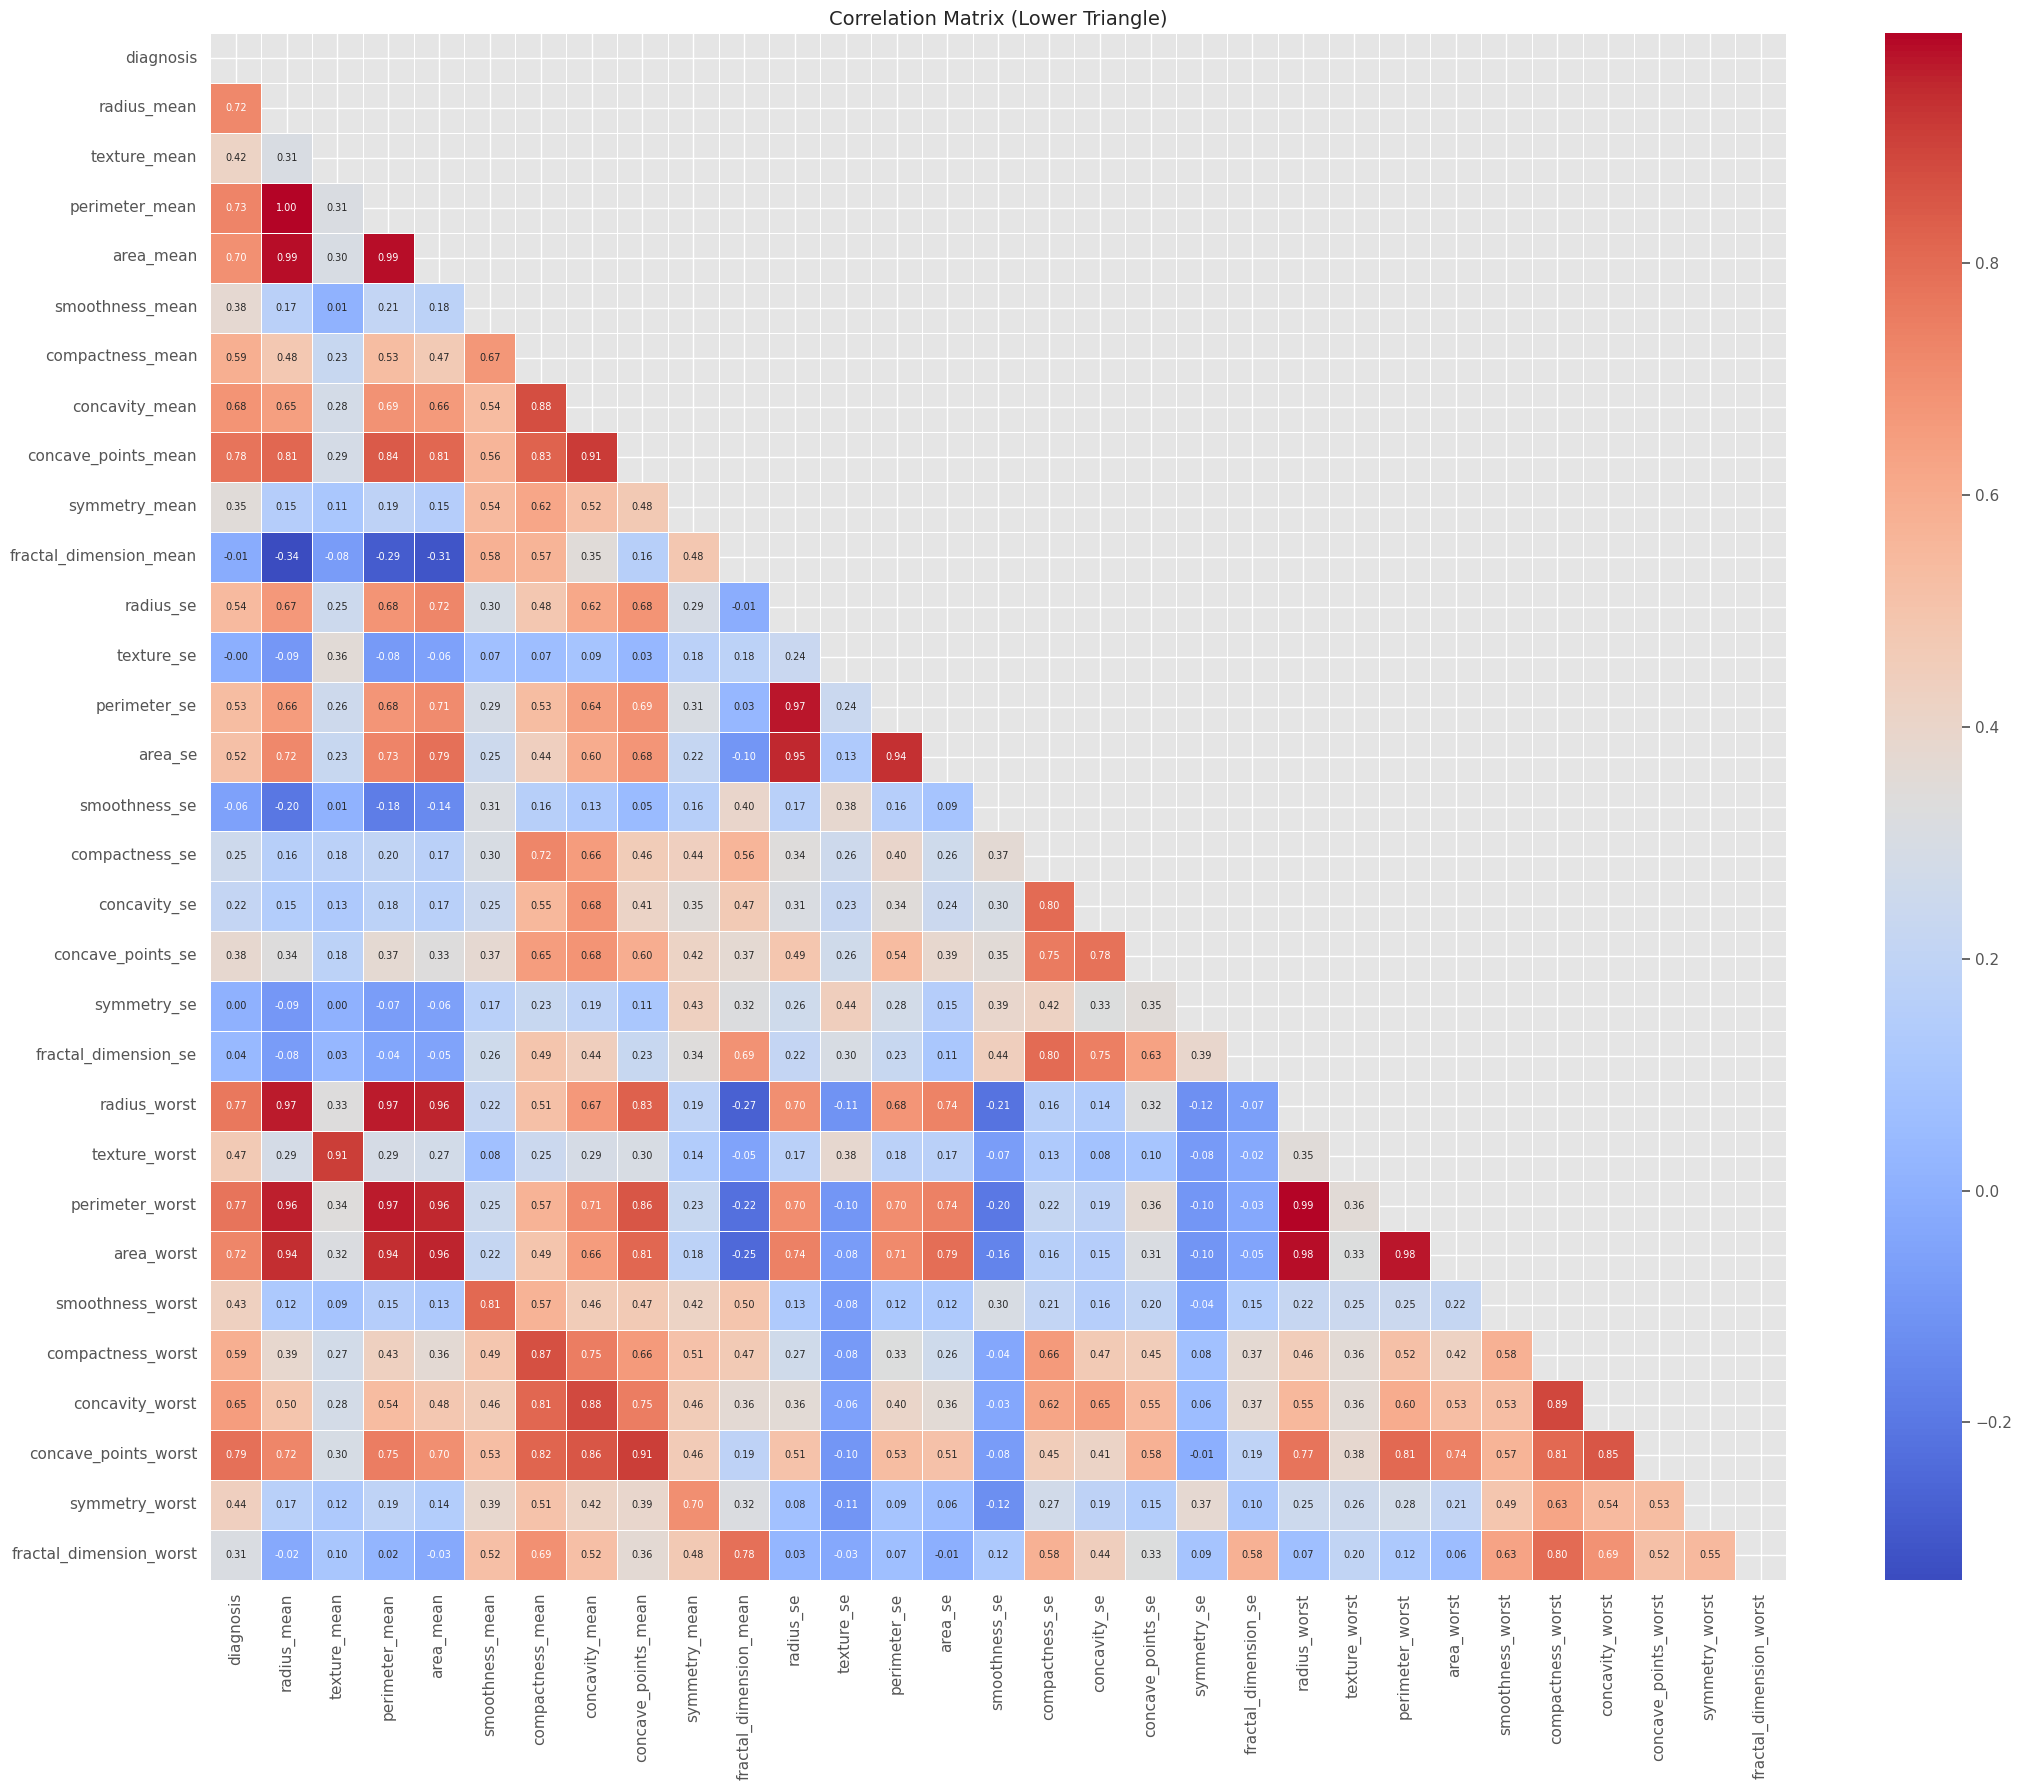

In [12]:
plt.figure(figsize=(22, 18))
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, linewidths=0.5, annot=True, fmt='.2f',
            cmap='coolwarm', annot_kws={'size': 7})
plt.title('Correlation Matrix (Lower Triangle)', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
corr_matrix = data.corr().abs()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_df = corr_matrix.mask(mask)

threshold = 0.92
to_drop = [c for c in tri_df.columns if any(tri_df[c] > threshold)]

print(f"Threshold: {threshold}")
print(f"Features to drop ({len(to_drop)}): {to_drop}")

data = data.drop(columns=to_drop)
print(f"Remaining features: {data.shape[1] - 1}")  # -1 for diagnosis
data.shape

Threshold: 0.92
Features to drop (7): ['radius_mean', 'perimeter_mean', 'area_mean', 'radius_se', 'perimeter_se', 'radius_worst', 'perimeter_worst']
Remaining features: 23


(455, 24)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class distribution:\n{y_train.value_counts().to_string()}")

Train: (364, 23), Test: (91, 23)
Train class distribution:
diagnosis
0    229
1    135


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred   = model.predict(X_te)
    y_proba  = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    test_acc  = accuracy_score(y_te, y_pred)
    auc       = roc_auc_score(y_te, y_proba) if y_proba is not None else None

    print(f"{'='*50}")
    print(f"Model: {name}")
    print(f"  Train Accuracy : {train_acc:.4f}")
    print(f"  Test  Accuracy : {test_acc:.4f}")
    if auc: print(f"  ROC-AUC        : {auc:.4f}")
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_te, y_pred)
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Benign', 'Malignant']))

    return test_acc, auc, y_proba

log_reg = LogisticRegression(max_iter=1000, random_state=42)
lr_acc, lr_auc, lr_proba = evaluate_model(log_reg, X_train, X_test, y_train, y_test, 'Logistic Regression')

Model: Logistic Regression
  Train Accuracy : 0.9890
  Test  Accuracy : 0.9890
  ROC-AUC        : 0.9979

Confusion Matrix:
[[57  0]
 [ 1 33]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99        57
   Malignant       1.00      0.97      0.99        34

    accuracy                           0.99        91
   macro avg       0.99      0.99      0.99        91
weighted avg       0.99      0.99      0.99        91



En iyi K: 9, Accuracy: 0.9670


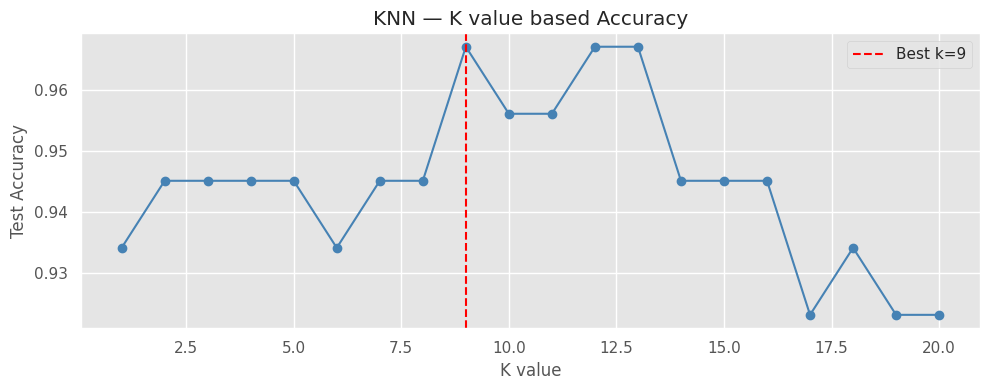

Model: KNN (k=9)
  Train Accuracy : 0.9533
  Test  Accuracy : 0.9670
  ROC-AUC        : 0.9889

Confusion Matrix:
[[57  0]
 [ 3 31]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        57
   Malignant       1.00      0.91      0.95        34

    accuracy                           0.97        91
   macro avg       0.97      0.96      0.96        91
weighted avg       0.97      0.97      0.97        91



In [16]:
from sklearn.neighbors import KNeighborsClassifier

k_scores = []
for k in range(1, 21):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    k_scores.append(accuracy_score(y_test, knn_k.predict(X_test)))

best_k = np.argmax(k_scores) + 1
print(f"En iyi K: {best_k}, Accuracy: {k_scores[best_k-1]:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(range(1, 21), k_scores, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K value')
plt.ylabel('Test Accuracy')
plt.title('KNN — K value based Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn_acc, knn_auc, knn_proba = evaluate_model(knn, X_train, X_test, y_train, y_test, f'KNN (k={best_k})')

In [17]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc = SVC(probability=True)
params = {
    'C'     : [0.1, 1, 10],
    'gamma' : [0.001, 0.01, 0.1],
    'kernel': ['rbf']
}
grid_svc = GridSearchCV(svc, params, cv=5, n_jobs=-1, verbose=0)
grid_svc.fit(X_train, y_train)

print(f"The best parameters: {grid_svc.best_params_}")
print(f"CV Score: {grid_svc.best_score_:.4f}")

best_svc = grid_svc.best_estimator_
svc_acc, svc_auc, svc_proba = evaluate_model(best_svc, X_train, X_test, y_train, y_test, 'SVM (GridSearchCV)')

The best parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
CV Score: 0.9753
Model: SVM (GridSearchCV)
  Train Accuracy : 0.9863
  Test  Accuracy : 0.9780
  ROC-AUC        : 0.9985

Confusion Matrix:
[[57  0]
 [ 2 32]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.98        57
   Malignant       1.00      0.94      0.97        34

    accuracy                           0.98        91
   macro avg       0.98      0.97      0.98        91
weighted avg       0.98      0.98      0.98        91



In [18]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)
params_dt = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_leaf' : [1, 2, 5],
    'min_samples_split': [2, 5, 10]
}
grid_dt = GridSearchCV(dtc, params_dt, cv=5, n_jobs=-1, verbose=0)
grid_dt.fit(X_train, y_train)

print(f"The best parameters: {grid_dt.best_params_}")
print(f"CV Score: {grid_dt.best_score_:.4f}")

best_dtc = grid_dt.best_estimator_
dtc_acc, dtc_auc, dtc_proba = evaluate_model(best_dtc, X_train, X_test, y_train, y_test, 'Decision Tree')

The best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
CV Score: 0.9643
Model: Decision Tree
  Train Accuracy : 0.9918
  Test  Accuracy : 0.9341
  ROC-AUC        : 0.9479

Confusion Matrix:
[[55  2]
 [ 4 30]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.96      0.95        57
   Malignant       0.94      0.88      0.91        34

    accuracy                           0.93        91
   macro avg       0.93      0.92      0.93        91
weighted avg       0.93      0.93      0.93        91



In [19]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators=200, criterion='entropy',
    max_depth=10, max_features='sqrt',
    min_samples_leaf=2, min_samples_split=3,
    random_state=42, n_jobs=-1
)
rfc_acc, rfc_auc, rfc_proba = evaluate_model(rfc, X_train, X_test, y_train, y_test, 'Random Forest')

Model: Random Forest
  Train Accuracy : 0.9973
  Test  Accuracy : 0.9560
  ROC-AUC        : 0.9948

Confusion Matrix:
[[54  3]
 [ 1 33]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.95      0.96        57
   Malignant       0.92      0.97      0.94        34

    accuracy                           0.96        91
   macro avg       0.95      0.96      0.95        91
weighted avg       0.96      0.96      0.96        91



In [21]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    colsample_bytree=0.8, eval_metric='logloss',
    use_label_encoder=False, random_state=42
)
xgb_acc, xgb_auc, xgb_proba = evaluate_model(xgb, X_train, X_test, y_train, y_test, 'XGBoost')

Model: XGBoost
  Train Accuracy : 1.0000
  Test  Accuracy : 0.9560
  ROC-AUC        : 0.9954

Confusion Matrix:
[[54  3]
 [ 1 33]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.95      0.96        57
   Malignant       0.92      0.97      0.94        34

    accuracy                           0.96        91
   macro avg       0.95      0.96      0.95        91
weighted avg       0.96      0.96      0.96        91



              Model  Accuracy  ROC-AUC
                SVM  0.978022 0.998452
Logistic Regression  0.989011 0.997936
            XGBoost  0.956044 0.995356
      Random Forest  0.956044 0.994840
                KNN  0.967033 0.988906
      Decision Tree  0.934066 0.947884


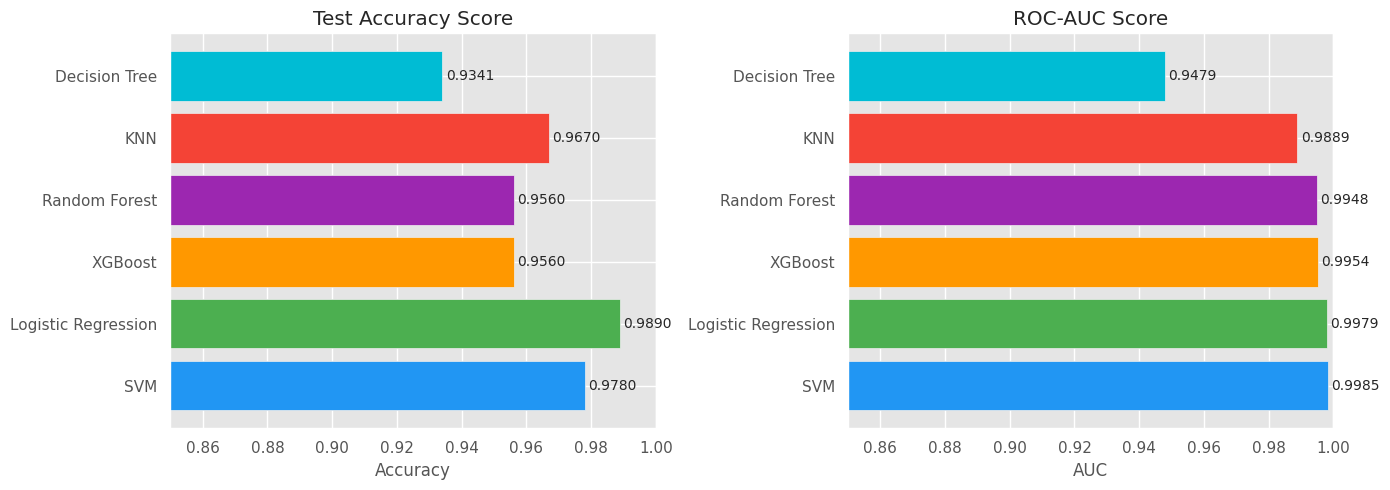

In [23]:
model_names  = ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest', 'XGBoost']
accuracies   = [lr_acc, knn_acc, svc_acc, dtc_acc, rfc_acc, xgb_acc]
aucs         = [lr_auc, knn_auc, svc_auc, dtc_auc, rfc_auc, xgb_auc]

results_df = pd.DataFrame({
    'Model'   : model_names,
    'Accuracy': accuracies,
    'ROC-AUC' : aucs
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

axes[0].barh(results_df['Model'], results_df['Accuracy'], color=colors)
axes[0].set_xlim(0.85, 1.0)
axes[0].set_title('Test Accuracy Score')
axes[0].set_xlabel('Accuracy')
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

axes[1].barh(results_df['Model'], results_df['ROC-AUC'], color=colors)
axes[1].set_xlim(0.85, 1.0)
axes[1].set_title('ROC-AUC Score')
axes[1].set_xlabel('AUC')
for i, v in enumerate(results_df['ROC-AUC']):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

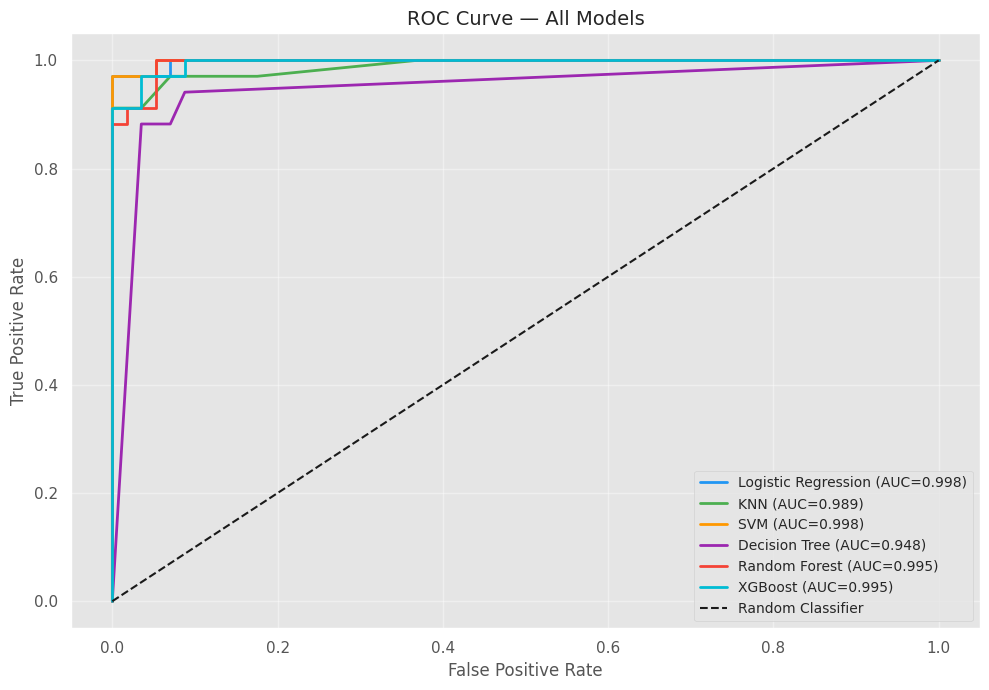

In [24]:
from sklearn.metrics import roc_curve, auc as auc_fn

fig, ax = plt.subplots(figsize=(10, 7))

probas = [lr_proba, knn_proba, svc_proba, dtc_proba, rfc_proba, xgb_proba]
colors_roc = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

for name, proba, col in zip(model_names, probas, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc_fn(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=col, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — All Models', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [26]:
import pickle

with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)

# Scaler'ı da kaydet (şart!)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
